# MOF Images Dataset Curation

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# 1) Import Images Dataset

In [2]:
data_dir = os.getcwd()
files_ab = os.path.join(data_dir, "2D_Grids_vdw_ab_plane.npz")
files_ac = os.path.join(data_dir, "2D_Grids_vdw_ac_plane.npz")
files_bc = os.path.join(data_dir, "2D_Grids_vdw_bc_plane.npz")

# Load data
data_ab = np.load(files_ab, allow_pickle=True)
data_ac = np.load(files_ac, allow_pickle=True)
data_bc = np.load(files_bc, allow_pickle=True)

images_ab = data_ab["images"] 
images_ac = data_ac["images"]   
images_bc = data_bc["images"]   

names_ab = data_ab["names"].tolist()
names_ac = data_ac["names"].tolist()
names_bc = data_bc["names"].tolist()

print(f"Loaded {len(images_ab)}")
print(f"Shape of first image: {images_ab[0].shape}")

Loaded 6996
Shape of first image: (500, 500)


# 2) Select Pore Plane Based on Image Void Fraction

In [3]:
names = []
images= []

count_ab = 0; count_ac = 0; count_bc = 0

for i, (image_ab, image_ac, image_bc) in enumerate(zip(images_ab, images_ac, images_bc)):
    total = image_ab.size
    void_fractions = [
        np.count_nonzero(image_ab) / total,
        np.count_nonzero(image_ac) / total,
        np.count_nonzero(image_bc) / total
    ]
    idx = np.argmax(void_fractions)  # select plane with highest void fraction
    
    images.append([image_ab, image_ac, image_bc][idx])
    names.append([names_ab[i], names_ac[i], names_bc[i]][idx])

    # Count which plane was selected
    if idx == 0:
        count_ab += 1
    elif idx == 1:
        count_ac += 1
    elif idx == 2:
        count_bc += 1

 # --- Summary ---
print("\n--- Plane selection summary ---")
print(f"ab selected: {count_ab} --> {100*count_ab/len(names):.2f} %")
print(f"ac selected: {count_ac} --> {100*count_ac/len(names):.2f} %")
print(f"bc selected: {count_bc} --> {100*count_bc/len(names):.2f} %")
print(f"Total images: {len(names)}")       



--- Plane selection summary ---
ab selected: 3564 --> 50.94 %
ac selected: 1287 --> 18.40 %
bc selected: 2145 --> 30.66 %
Total images: 6996


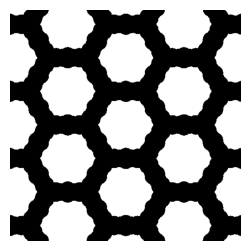

In [4]:
#visulizae one example
selected_name = "HAYYUE_full"
index = names.index(selected_name)
img = images[index]

plt.figure(figsize=(3,3))
plt.imshow(img, cmap='gray')
plt.axis("off")
plt.show()

In [5]:
# --- Save compressed ---
out_file = os.path.join(data_dir, "2D_Grids_vdw_selected_plane.npz")
np.savez_compressed(out_file, images=images, names=names)

# 3) Remove Images with Low Porousity

In [6]:
def remove_dense_images(images, names, threshold=0.05):
    VF = [np.count_nonzero(img) / img.size for img in images]
    keep_idx = [i for i, vf in enumerate(VF) if vf > threshold]  # keep VF > threshold

    images_filtered = [images[i] for i in keep_idx]
    names_filtered = [names[i] for i in keep_idx]
    
    return images_filtered, names_filtered

In [7]:
images_filtered, names_filtered = remove_dense_images(images, names, threshold=0.05)

print("Initial images:", len(names))
print("Removed dense images:", len(names) - len(names_filtered))
print("Remaining names:", len(names_filtered))


Initial images: 6996
Removed dense images: 1346
Remaining names: 5650


# 4) Remove Duplicate Images

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

def compute_cosine_similarity_matrices(images):

    # Flatten images
    vectors = np.array([img.flatten() for img in images])

    # Original similarity
    sim_pore = cosine_similarity(vectors)

    # Frame (background flipped) similarity
    vectors_frame = 1 - vectors
    sim_frame = cosine_similarity(vectors_frame)

    sim_avg = 0.5 * (sim_pore + sim_frame)

    return sim_pore, sim_frame, sim_avg


In [9]:
sim_matrix_pore, sim_matrix_frame, sim_matrix_avg = compute_cosine_similarity_matrices(images_filtered)

In [10]:
def remove_duplicates(images, names, sim_matrix, threshold=0.95):

    keep = []
    grouped_duplicates = {}

    for i in range(len(names)):
        is_duplicate = False

        for j in keep:
            if sim_matrix[i, j] >= threshold:
                grouped_duplicates.setdefault(names[j], []).append(names[i])
                is_duplicate = True
                break

        if not is_duplicate:
            keep.append(i)

    unique_images = [images[i] for i in keep]
    unique_names = [names[i] for i in keep]

    return unique_images, unique_names, grouped_duplicates


In [11]:
images_curated, names_curated, duplicates = remove_duplicates(images_filtered, names_filtered, sim_matrix_avg, threshold=0.95)

print("Removed duplicates:", sum(len(v) for v in duplicates.values()))
print("Remaining images:", len(images_curated))


Removed duplicates: 1795
Remaining images: 3855


In [12]:
# --- Save compressed ---
out_file = os.path.join(data_dir, "2D_Grids_vdw_curated.npz")
np.savez_compressed(out_file, images=images_curated, names=names_curated)